<a href="https://colab.research.google.com/github/jorobledo/blcourse_test/blob/main/BLcourse4/colab/flows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Initialize Colab
!git clone https://github.com/jorobledo/bayesian_learning_course.git
%cd bayesian_learning_course/BLcourse4/colab/
!pip install -q zuko

# Normalizing Flows

The VAE was our first example of a generative model that is capable of sampling from $P(x)$. A VAE can also estimate $P(x)$ by going from the encoder to $z$, and then using the known distribution $P(z)$. However, VAEs typically are not great at either tasks. Their samples are often described as "blurry" because they have mean-seeking behavior. That is, the individual samples do not correspond to a very likely example (not mode-seeking). Instead the distribution of samples is good (mean-seeking). **Generative adversarial networks** (GANs) are an alternative to VAEs which have high probability samples. However, both methods suffer often have training problems and also give poor estimates of $P(x)$ because of both lack of normalization and assumptions of normal distributions. An alternative is a **normalizing flow** that has better stability training and better estimates of $P(x)$. Normalizing flows are also used as components in other networks, like it can act as $P(z)$ of a latent space for a VAE instead of standard normal distributions. 


You can construct interesting bijective functions between $\mathbb{R}^2$ and $\mathbb{R}$, but in the case of finite precision on a computer this is not possible so we can work with the slightly imprecise heuristic that functions need to have the same number of inputs and outputs to be bijective. 

A **normalizing flow** is similar to a VAE in that we try to build up $P(x)$ by starting from a simple known distribution $P(z)$. We use functions, like the decoder from a VAE, to go from $x$ to $z$. However, we make sure that the functions we choose keep the probability mass normalized ($\sum P(x) = 1$) and can be used forward (to sample from x) and backward (to compute $P(x)$). We call these functions **bijectors** because they are bijective (surjective and injective). Recall surjective (onto) means every output has a corresponding input and injective (onto) means each output has exactly one corresponding input.

An example of a bijector is an element-wise cosine $y_i = \cos x_i$ (assuming $x_i$ is between $0$ and $\pi$). A non-bijective function would be $y_i = \cos x_i$ on the interval from $0$ to $2\pi$, because it outputs all values from $[0,1]$ twice and hence is not injective. Any function which changes the number of elements is automatically not bijective (see margin note). A consequence of using only bijectors in constructing our normalizing flow is that the size of the latent space must be equal to the size of the feature space. Remember the VAE used a smaller latent space than the feature space. 


Audience & Objectives
This chapter builds on {doc}`VAE` and assumes the same background of probability theory. This chapter is an introduction to the key ideas, but is not fully developed yet. Some knowledge of vector calculus (Jacobians) is assumed as well. After completing it, you should be able to 

  * Understand the trade-offs between a VAE, GAN, and normalizing flow. 
  * Identify a bijector and construct a bijector chain
  * Construct a normalizing flow using common bijectors types and train it
  * Sample from a normalizing flow and compute sample probabilities  


You can find a recent review of normalizing [flows here](https://arxiv.org/pdf/1908.09257.pdf) {cite}`kobyzev2020normalizing` and [here](https://arxiv.org/abs/1912.02762){cite}`papamakarios2019normalizing`. Although generating images and sound is the most popular application of normalizing flows, some of their biggest scientific impact has been on more efficient sampling from posteriors or likelihoods and other complex probability distributions {cite}`papamakarios2019sequential`. You find details on how to do normalizing flows on categorical (discrete) data in Hoogeboom et al. {cite}`hoogeboom2021argmax`.

## Flow Equation

Recall for the VAE decoder, we had an explicit formula for $p(x | z)$. This allowed us to compute $p(x) = \int\,dz p(x | z)p(z)$ which is the quantity of interest. The VAE decoder is a conditional probability density function. In the normalizing flow, we do not use probability density functions. We use bijective functions. So we cannot just compute an integral to change variables. We can use the change of variable formula. Consider our normalizing flow to be defined by our bijector $x = f(z)$, its inverse $z = g(x)$, and the starting probability distribution $P_z(z)$. Then the formula for probability of $x$ is

\begin{equation}
P(x) = P_z\left(g(x)\right) \,\left| \textrm{det}\left[\mathbf{J}_g\right]\right|
\end{equation}

where the term on the right is the absolute value of the determinant of the Jacobian of $g$. [Jacobians](https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant) are matrices that describe how infinitesimal changes in each domain dimension change each range dimension. This term corrects for the volume change of the distribution. For example, if $f(z) = 2z$, then $g(x) = x / 2$, and the Jacobian determinant is $1 / 2$. The intuition is that we are stretching out $z$ by 2, so we need to account for the increase in volume to keep the probability normalized. You can read more about the change of variable formula for [probability distributions here](https://cranmer.github.io/stats-ds-book/distributions/change-of-variables.html)


## Bijectors

A bijector is a function that is [injective](https://en.wikipedia.org/wiki/Injective_function) (1 to 1) and [surjective](https://en.wikipedia.org/wiki/Surjective_function) (onto). An equivalent way to view a bijective function is if it has an inverse.  Multiplying by a matrix which has an inverse is bijective. $y = x^2$ is not bijective, since $y = 4$ has two solutions. 

Remember that we must compute the determinant of the bijector Jacobian. If the Jacobian is dense (all output elements depend on all input elements), computing this quantity will be $O\left(|x|_0^3\right)$ where $|x|_0$ is the number of dimensions of $x$ because a determinant scales by $O(n^3)$. This would make computing normalizing flows impractical in high-dimensions. However, in practice we restrict ourselves to bijectors that have easy to calculate Jacobians. For example, if the bijector is $x_i = \cos z_i$ then the Jacobian will be diagonal. Such a diagonal Jacobian means that each dimension is independent of the other though. 

One way to get faster determinants without just making each dimension independent is to get a triangular Jacobian. Then $x_0$ only depends on $z_0$, $x_1$ depends on $z_0, z_1$, and $x_2$ depends on $z_0, z_1, z_2$, etc. This enables fitting high-dimensional correlations for some of the dimensions (like $x_{n}$). The matrix determinant of a triangular matrix is computed in linear time with respect to the number of dimensions -- because it is just the product of the matrix diagonal. 

### Bijector Chains

Just like in deep neural networks, multiple bijectors are chained together to increase how complex of the final fit distribution $\hat{P}(x)$ can be. The change of variable equation can be repeatedly applied:

\begin{equation}
P(x) = P_z\left[g_1\left(g_0(x)\right)\right] \,\left| \textrm{det}\left[\mathbf{J}_{g_1}\right]\right|  \left|\textrm{det}\left[\mathbf{J}_{g_0}\right]\right|
\end{equation}

where we would compute $x$ with $f_0\left(f_1(z)\right)$. One critical point is that you should also include a **permute bijector** that swaps the order of dimensions. Since the bijectors typically have triangular Jacobians, certain output dimensions will depend on many input dimensions and others will only depend on a single one. By applying a permutation, you allow each dimension to influence each other.


## Training

At this point, you may be wondering how you could possibly train a normalizing flow. The trainable parameters appear in the bijectors. They have adjustable parameters. The loss equation is quite simple: the negative log-likelihood (negative to make it minimization). Explicitly:

\begin{equation}
\mathcal{l} = -\log P_z\left[g_1\left(g_0(x)\right)\right] - \sum_i \log\left| \textrm{det}\left[\mathbf{J}_{g_i}\right]\right|
\end{equation}

where $x$ is the training point and when you take the gradient of the loss, it is with respect to the parameters of the bijectors. 


## Common Bijectors

The choice of bijector functions is a fast changing area. I will thus only mention a few. You can of course use any bijective function or matrix, but these become inefficient at high-dimension due to the Jacobian calculation. One class of efficient bijectors are autoregressive bijectors. These have triangular Jacobians because each output dimension can only depend on the dimensions with a lower index. There are two variants: masked autoregressive flows (MAF){cite}`papamakarios2017masked` and inverse autoregressive flows (IAF) {cite}`kingma2016improved`. MAFs are efficient at training and computing probabilities, but are slow for sampling from $P(x)$. IAFs are slow at training and computing probabilities but efficient for sampling. Wavenets combine the advantages of both {cite}`kim2018flowavenet`. I'll mention one other common bijector which is not autoregressive: real non-volume preserving (RealNVPs) {cite}`dinh2016density`. RealNVPs are less expressive than IAFs/MAFs, meaning they have trouble replicating complex distributions, but are efficient at all three tasks: training, sampling, and computing probabilities. Another interesting variant is the Glow bijector,which is able to expand the rank of the normalizing flow, for example going from a matrix to an RGB image {cite}`das2019dimensionality`. What are the equations for all these bijectors? Most are variants of standard neural network layers but with special rules about which outputs depend on which inputs. 


Remember to add permute bijectors between autoregressive bijectors to ensure the dependence between dimensions is well-mixed.



The hidden code below imports the Zuko normalizing flow package package and other necessary packages.

In [1]:
import zuko 
%matplotlib inline
import sklearn.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(0)
torch.manual_seed(0)


## Moon Example

We'll start with a basic 2D example to learn the two moons distribution with a normalizing flow. Two moons is a common example dataset that is hard to cluster and model as a probability distribution. 

When doing normalizing flows you have two options to implement them. You can do all the Jacobians, inverses, and likelihood calculations analytically and implement them in a normal ML framework like Jax, PyTorch, or TensorFlow. This is actually most common. The second option is to utilize a probability library that knows how to use bijectors and distributions. Some packages for that are PYMC, TensorFlow Probability (which has a non-tensorflow JAX version confusingly), Pyro (Pytorch), and Zuko (PyTorch). We'll use [Zuko](https://zuko.readthedocs.io/stable/index.html) for this work.

### Generating Data

In the code below, we set-up our imports and sample points which will be used for training. Remember, this code has nothing to do with normalizing flows -- it's just to generate data.

In [2]:
moon_n = 10000
ndim = 2
data, labels = datasets.make_moons(moon_n, noise=0.05)

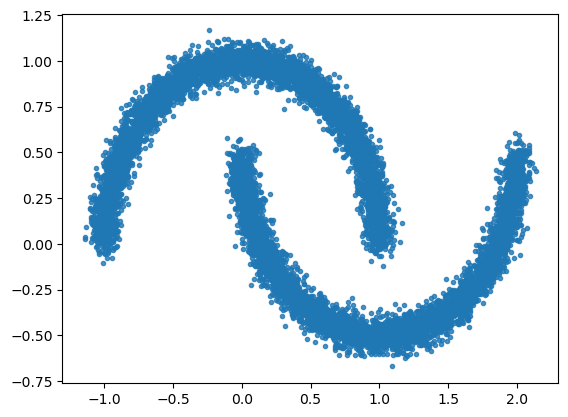

In [3]:
plt.plot(data[:, 0], data[:, 1], ".", alpha=0.8)

### Z Distribution

Our Z distribution should always be as simple as possible. I'll create a 2D Gaussian with unit variance, no covariance, and centered at 0 using `PyTorch`.

In [4]:
from torch.distributions import MultivariateNormal
import torch

loc  = torch.zeros(ndim)
cov = torch.eye(ndim)

zdist = MultivariateNormal(loc=loc, covariance_matrix=cov)
zdist

MultivariateNormal(loc: torch.Size([2]), covariance_matrix: torch.Size([2, 2]))

Let's now sample from this distribution and view it

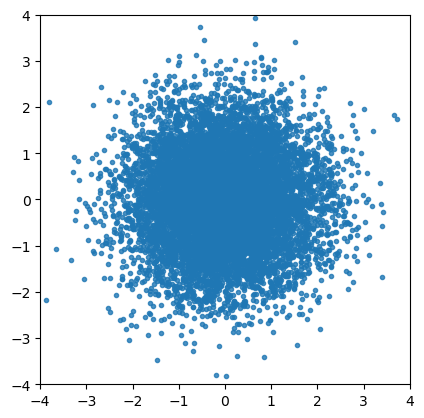

In [5]:
zsamples = zdist.sample((moon_n,)).numpy()
plt.plot(zsamples[:, 0], zsamples[:, 1], ".", alpha=0.8)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect("equal")

As expected, our starting distribution looks nothing like are target distribution. Let's demonstrate a bijector now. We'll implement the following bijector:

$$
x = \vec{z} \times (1, 0.5)^T + (0.5, 0.25)
$$

This is bijective because the operations are element-wise and invertible. Rather than just write this out using operations like `@` or `*`, we'll use the built-in bijectors from `PyTorch` and `Zuko`. The reason we do this is that they have their inverses and Jacobian determinants already defined. We first create a bijector that scales by `[1, 0.5]` and one then one that shifts by `[0.5,0.25]`. Note that we will do two equivalent ways, one for each package, and we'll see that we can use any alternative.

In [6]:
from torch.distributions import TransformedDistribution
from torch.distributions.transforms import AffineTransform
t = torch.tensor([0.5, 0.25])
s = torch.tensor([1.0, 0.5])

# Native pytorch transform
transform_pytorch = AffineTransform(loc=t, scale=s)
dist_pytorch = TransformedDistribution(zdist, transform_pytorch)

# Zuko version of the same transform
transform_zuko = zuko.transforms.MonotonicAffineTransform(shift=t, scale=s.log())
dist_zuko = TransformedDistribution(zdist, transform_zuko)

To apply the change of variable formula, we created a **transformed distribution**. What is important about this choice is that we can compute likelihoods, probabilities, and sample from it.

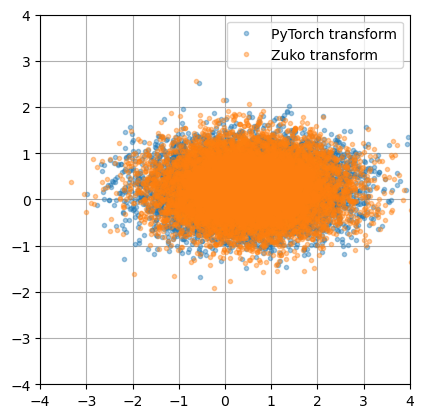

In [7]:
zsamples_pytorch = dist_pytorch.sample((moon_n,))
zsamples_zuko = dist_zuko.sample((moon_n,))
plt.plot(zsamples_pytorch[:, 0], zsamples_pytorch[:, 1], ".", alpha=0.4, label="PyTorch transform")
plt.plot(zsamples_zuko[:, 0], zsamples_zuko[:, 1], ".", alpha=0.4, label="Zuko transform")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.grid()
plt.gca().set_aspect("equal")
plt.legend()

We show above the sampling from this new distribution. We can also plot it's probability, which is impossible for a VAE-like model!

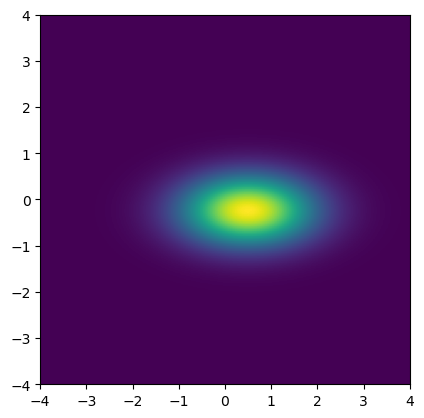

In [8]:
# make points for grid
zpoints = torch.linspace(-4, 4, 150)
z1,z2 = torch.meshgrid(zpoints, zpoints, indexing="xy")
zgrid = torch.cat((z1.reshape(-1, 1), z2.reshape(-1, 1)), dim=1)

# compute P(x)
p = torch.exp(dist_zuko.log_prob(zgrid))
fig = plt.figure()

# plot and set axes limits
plt.imshow(p.reshape(z1.shape), aspect="equal", extent=[-4, 4, -4, 4])
plt.show()

You may see the distribution shifted and scaled as expected by the given values.

### The Normalizing Flow

Now we will build bijectors that are expressive enough to capture the moon distribution. We will use a total of 6 bijectors. MAF's have dense neural network layers in them, so I will also set the usual parameters for a neural network: dimension of hidden layer and activation. Note that `randperm` allow for the random permutations ib between of each transform.

In [9]:
anet = zuko.flows.autoregressive.MAF(features=ndim,
                                     context=0,
                                     transforms=6, 
                                     hidden_features=[128, 128], 
                                     activation = torch.nn.ReLU,
                                     randperm=True)
anet

MAF(
  (transform): LazyComposedTransform(
    (0-1): 2 x MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order): [0, 1]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=2, out_features=128, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=128, out_features=4, bias=True)
      )
    )
    (2-4): 3 x MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order): [1, 0]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=2, out_features=128, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=128, out_features=4, bias=True)
      )
    )
    (5): MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order): [0, 1]
      (hyper): MaskedMLP(
        (0): MaskedLinear(

Note that we do not provide a context (conditioning variable to estimate conditional probabilities), so we set `context=0`. Nevertheless, we could provide it in this example, since we do have the labels from our moon shape data, where `label=0` for the upper moon data and `label=1` for the lower moon data. Then we could learn the conditional probability $P(x|c)$, where $c=0,1$ indicating from which moon the data came from. In this case, we would define `context=1` since there is one context variable, and then we would also need to pass it to the normalizing flow during the training.

Note aside and going back to no context example, we can do the same as before, and apply the bijectors we just defined to our original normal distribution:

In [10]:
dist_transformed = TransformedDistribution(zdist, anet().transform)

At this point, we have not actually trained but we can still view our distribution. 

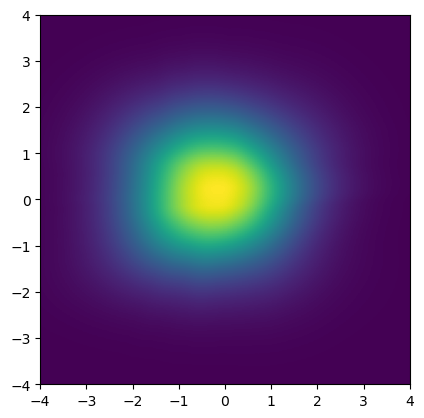

In [11]:
# compute P(x)
p = torch.exp(dist_transformed.log_prob(zgrid)).detach()
fig = plt.figure()

# plot and set axes limits
plt.imshow(p.reshape(z1.shape), aspect="equal", extent=[-4, 4, -4, 4])
plt.show()

You can already see that the distribution looks more complex than a Gaussian. 

### Training


Since we are going to train using `PyTorch`, we must transform our data to tensors, and then create a tensor dataset, as well as a dataloader:

In [12]:
t_data = torch.from_numpy(data).float()
t_labels = torch.from_numpy(labels).float()

trainset = torch.utils.data.TensorDataset(t_data, t_labels)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

In [13]:
optimizer = torch.optim.Adam(anet.parameters(), lr=1e-3)

total_loss = []
for epoch in range(30):
    losses = []
    for x, label in trainloader:
        optimizer.zero_grad()
        loss = -anet().log_prob(x).mean()
        loss.backward()
        optimizer.step()
        losses.append(loss.detach())

    losses = torch.stack(losses)

    print(f"Epoch {epoch} - Loss: {losses.mean():.3f} +/- {losses.std():.3f}")
    total_loss.append(losses.mean().item())

Epoch 0 - Loss: 1.334 +/- 0.260
Epoch 1 - Loss: 0.932 +/- 0.164
Epoch 2 - Loss: 0.785 +/- 0.128
Epoch 3 - Loss: 0.722 +/- 0.121
Epoch 4 - Loss: 0.723 +/- 0.158
Epoch 5 - Loss: 0.638 +/- 0.131
Epoch 6 - Loss: 0.661 +/- 0.124
Epoch 7 - Loss: 0.634 +/- 0.115
Epoch 8 - Loss: 0.615 +/- 0.115
Epoch 9 - Loss: 0.598 +/- 0.128
Epoch 10 - Loss: 0.597 +/- 0.120
Epoch 11 - Loss: 0.593 +/- 0.128
Epoch 12 - Loss: 0.589 +/- 0.131
Epoch 13 - Loss: 0.582 +/- 0.123
Epoch 14 - Loss: 0.573 +/- 0.137
Epoch 15 - Loss: 0.567 +/- 0.138
Epoch 16 - Loss: 0.555 +/- 0.124
Epoch 17 - Loss: 0.566 +/- 0.134
Epoch 18 - Loss: 0.552 +/- 0.137
Epoch 19 - Loss: 0.544 +/- 0.128
Epoch 20 - Loss: 0.550 +/- 0.139
Epoch 21 - Loss: 0.533 +/- 0.132
Epoch 22 - Loss: 0.533 +/- 0.133
Epoch 23 - Loss: 0.544 +/- 0.151
Epoch 24 - Loss: 0.528 +/- 0.112
Epoch 25 - Loss: 0.553 +/- 0.165
Epoch 26 - Loss: 0.534 +/- 0.129
Epoch 27 - Loss: 0.525 +/- 0.131
Epoch 28 - Loss: 0.523 +/- 0.132
Epoch 29 - Loss: 0.546 +/- 0.151


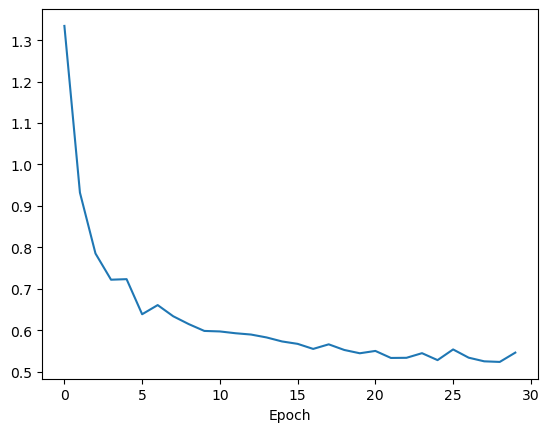

In [14]:
plt.figure()
plt.plot(total_loss)
plt.xlabel("Epoch")
plt.show()

Training looks reasonable. Let's now see our distribution. 

/tmp/ipykernel_37006/3412895270.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  p = np.exp(anet().log_prob(zgrid).detach())


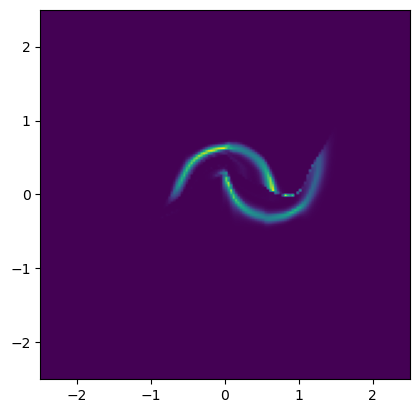

In [15]:
p = np.exp(anet().log_prob(zgrid).detach())
fig = plt.figure()
plt.imshow(
    p.reshape(z1.shape), aspect="equal", origin="lower", extent=[-2.5, 2.5, -2.5, 2.5]
)
plt.show()

Wow! We now can compute the probability of any point in this distribution. You can see there are some oddities that could be fixed with further training. One issue that cannot be overcome is the connection between the two curves -- it is not possible to get fully disconnected densities. This is because of our requirement that the bijectors are invertible and volume preserving -- you can only squeeze volume so far but cannot completely disconnect. Some work has been done on addressing this issue by adding sampling to the flow and this gives more expressive normalizing flows {cite}`wu2020stochastic`.

Finally, we'll sample from our model just to show that indeed it is generative.

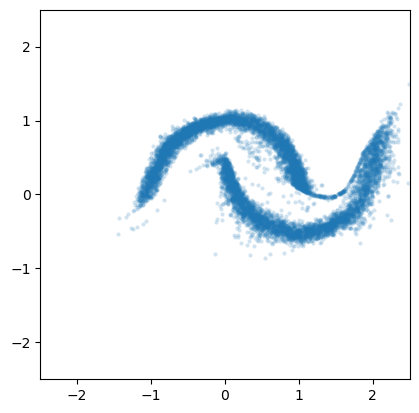

In [16]:
zsamples = anet().sample((moon_n,)).detach()
plt.plot(zsamples[:, 0], zsamples[:, 1], ".", alpha=0.2, markeredgewidth=0.0)
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.gca().set_aspect("equal")

## Chapter Summary 

* A normalizing flow builds up a probability distribution of $x$ by starting from a known distribution on $z$. Bijective functions are used to go from $z$ to $x$.
* Bijectors are functions that keep the probability mass normalized and are used to go forward and backward (because they have well-defined inverses).
* To find the probability distribution of $x$ we use the change of variable formula, which requires a function inverse and Jacobian.
* The bijector function has trainable parameters, which can be trained using a negative log-likelihood function. 
* Multiple bijectors can be chained together, but typically must include a permute bijector to swap the order of dimensions. 

## Cited References

```{bibliography}
:style: unsrtalpha
:filter: docname in docnames
```